# Machine Learning Lab: Classification, Recommendation & Clustering

**Organization:** DataVine Analytics  
**Projects:**
1. Wine Classification using k-Nearest Neighbors (k-NN) and PCA
2. Agricultural Feed Recommendation using PCA and cosine similarity
3. Regional Crime Pattern Analysis using K-Means and Gaussian Mixture Models (GMM)

 **data preparation → exploratory analysis → preprocessing → dimensionality reduction → model building → hyperparameter tuning → evaluation → visualization → interpretation**.


## Step 0 — Import Libraries

We use:
- `pandas` and `numpy` for data manipulation
- `matplotlib` and `seaborn` for visualization
- `scikit-learn` for preprocessing, PCA, classification, similarity, clustering, and evaluation


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    silhouette_score
)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 6)


## Step 1 — Load the Datasets

The three CSV files are loaded into pandas DataFrames.

In [3]:
wine_path = "wine.csv"
chickwts_path = "chickwts.csv"
usarrests_path = "USArrests.csv"

wine = pd.read_csv(wine_path)
chickwts = pd.read_csv(chickwts_path)
usarrests = pd.read_csv(usarrests_path)

print("Wine shape:", wine.shape)
print("Chickwts shape:", chickwts.shape)
print("USArrests shape:", usarrests.shape)


Wine shape: (178, 14)
Chickwts shape: (71, 2)
USArrests shape: (50, 5)


## Step 1.1 — Inspect Dataset Structure

In [4]:
display(wine.head())
display(chickwts.head())
display(usarrests.head())

print("\nWine information:")
wine.info()

print("\nChickwts information:")
chickwts.info()

print("\nUSArrests information:")
usarrests.info()


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


,weight,feed
0,179,horsebean
1,160,horsebean
2,136,horsebean
3,227,horsebean
4,217,horsebean


,rownames,Murder,Assault,UrbanPop,Rape
0,Alabama,13.2,236,58,21.2
1,Alaska,10.0,263,48,44.5
2,Arizona,8.1,294,80,31.0
3,Arkansas,8.8,190,50,19.5
4,California,9.0,276,91,40.6



Wine information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null   

## Step 1.2 — Check for Missing Values

Missing values can cause errors or unreliable results during preprocessing and model training.

In [5]:
print("Missing values in Wine:")
display(wine.isnull().sum())

print("Missing values in Chickwts:")
display(chickwts.isnull().sum())

print("Missing values in USArrests:")
display(usarrests.isnull().sum())


Missing values in Wine:


alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64

Missing values in Chickwts:


weight    0
feed      0
dtype: int64

Missing values in USArrests:


rownames    0
Murder      0
Assault     0
UrbanPop    0
Rape        0
dtype: int64

## Step 1.3 — Handle Missing Values and Duplicates

For these datasets, we check for duplicates and remove exact duplicate rows if any exist. Since the supplied datasets contain no missing values, no imputation is required.

In [6]:
print("Duplicate rows before cleaning:")
print("Wine:", wine.duplicated().sum())
print("Chickwts:", chickwts.duplicated().sum())
print("USArrests:", usarrests.duplicated().sum())

wine = wine.drop_duplicates().reset_index(drop=True)
chickwts = chickwts.drop_duplicates().reset_index(drop=True)
usarrests = usarrests.drop_duplicates().reset_index(drop=True)

print("\nShapes after cleaning:")
print("Wine:", wine.shape)
print("Chickwts:", chickwts.shape)
print("USArrests:", usarrests.shape)


Duplicate rows before cleaning:
Wine: 0
Chickwts: 1
USArrests: 0

Shapes after cleaning:
Wine: (178, 14)
Chickwts: (70, 2)
USArrests: (50, 5)


## Step 1.4 — Summary Statistics

In [7]:
print("Wine summary:")
display(wine.describe().T)

print("Chickwts summary:")
display(chickwts.describe(include="all").T)

print("USArrests summary:")
display(usarrests.describe().T)

Wine summary:


,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


Chickwts summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
weight,70.0,NaN,NaN,NaN,261.5,78.620857,108.0,203.75,259.0,324.25,423.0
feed,70,6,soybean,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN


USArrests summary:


,count,mean,std,min,25%,50%,75%,max
Murder,50.0,7.788,4.355510,0.8,4.075,7.25,11.250,17.4
Assault,50.0,170.760,83.337661,45.0,109.000,159.00,249.000,337.0
UrbanPop,50.0,65.540,14.474763,32.0,54.500,66.00,77.750,91.0
Rape,50.0,21.232,9.366385,7.3,15.075,20.10,26.175,46.0


# Part 1 — Wine Classification

### Objective
Build a k-NN classifier that predicts wine class from chemical measurements.

The workflow is:
1. Separate features and target
2. Encode the target if necessary
3. Split into training and testing sets
4. Standardize the numerical features
5. Apply PCA while retaining 95% of the variance
6. Tune k-NN with `GridSearchCV`
7. Evaluate accuracy and the classification report
8. Visualize the PCA representation and confusion matrix


## Step 2.1 — Prepare the Wine Data

In [8]:
X_wine = wine.drop(columns=["target"]).copy()
y_wine = wine["target"].copy()

# Convert target labels to numeric values when they are categorical.
if not pd.api.types.is_numeric_dtype(y_wine):
    wine_encoder = LabelEncoder()
    y_wine = wine_encoder.fit_transform(y_wine)
else:
    y_wine = y_wine.astype(int)

print("Feature matrix shape:", X_wine.shape)
print("Target shape:", y_wine.shape)
print("Target classes:", np.unique(y_wine))


Feature matrix shape: (178, 13)
Target shape: (178,)
Target classes: [0 1 2]


## Step 2.2 — Train/Test Split

A stratified split keeps the class proportions approximately consistent in both datasets.

In [9]:
X_train_wine, X_test_wine, y_train_wine, y_test_wine = train_test_split(
    X_wine,
    y_wine,
    test_size=0.20,
    random_state=42,
    stratify=y_wine
)

print("Training samples:", X_train_wine.shape[0])
print("Testing samples:", X_test_wine.shape[0])


Training samples: 142
Testing samples: 36


## Step 2.3 — Standardize the Wine Features

k-NN is distance-based, so features with large numerical scales must not dominate the distance calculation.

In [10]:
wine_scaler = StandardScaler()

X_train_wine_scaled = wine_scaler.fit_transform(X_train_wine)
X_test_wine_scaled = wine_scaler.transform(X_test_wine)

print("Training data mean after scaling:",
      np.round(X_train_wine_scaled.mean(axis=0), 3))
print("Training data standard deviation after scaling:",
      np.round(X_train_wine_scaled.std(axis=0), 3))


Training data mean after scaling: [ 0.  0. -0.  0.  0. -0. -0. -0.  0.  0. -0. -0. -0.]
Training data standard deviation after scaling: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## Step 2.4 — Apply PCA and Retain 95% Variance

PCA transforms the standardized features into a smaller set of uncorrelated principal components. We let `n_components=0.95` automatically choose enough components to preserve at least 95% of the variance.

In [11]:
wine_pca = PCA(n_components=0.95)

X_train_wine_pca = wine_pca.fit_transform(X_train_wine_scaled)
X_test_wine_pca = wine_pca.transform(X_test_wine_scaled)

print("Original number of features:", X_train_wine_scaled.shape[1])
print("Number of PCA components retained:", wine_pca.n_components_)
print("Explained variance ratio:")
print(np.round(wine_pca.explained_variance_ratio_, 4))
print("Total explained variance:",
      round(wine_pca.explained_variance_ratio_.sum(), 4))


Original number of features: 13
Number of PCA components retained: 10
Explained variance ratio:
[0.3579 0.1927 0.1102 0.0727 0.0672 0.0513 0.0438 0.025  0.0228 0.0188]
Total explained variance: 0.9624


## Step 2.5 — Visualize Wine PCA Variance

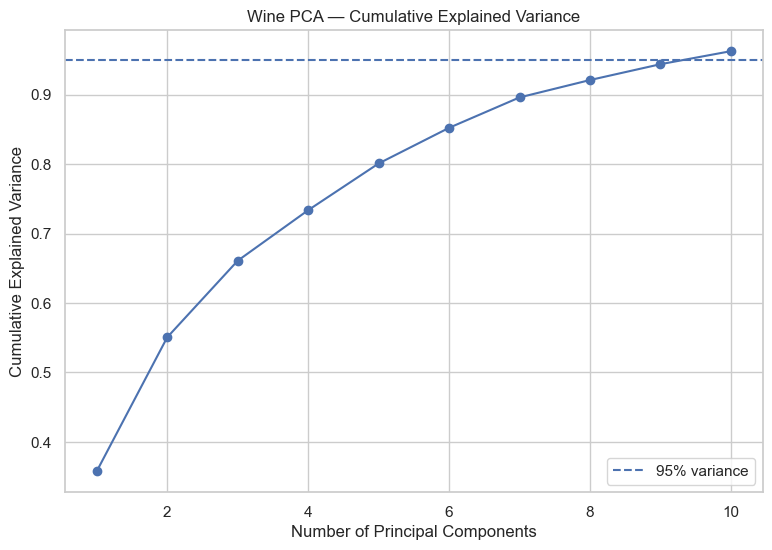

In [12]:
cumulative_variance = np.cumsum(wine_pca.explained_variance_ratio_)

plt.figure()
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)
plt.axhline(0.95, linestyle="--", label="95% variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Wine PCA — Cumulative Explained Variance")
plt.legend()
plt.show()


## Step 2.6 — Tune k-NN with GridSearchCV

We test several values of `k` and different distance metrics. The grid search uses 5-fold cross-validation on the training set.

For Minkowski distance, `p=2` corresponds to Euclidean distance and `p=1` corresponds to Manhattan distance.

In [13]:
knn = KNeighborsClassifier()

param_grid = {
    "n_neighbors": list(range(1, 16)),
    "metric": ["euclidean", "manhattan", "minkowski"],
    "weights": ["uniform", "distance"]
}

knn_grid = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

knn_grid.fit(X_train_wine_pca, y_train_wine)

print("Best parameters:")
print(knn_grid.best_params_)
print("\nBest cross-validation accuracy:",
      round(knn_grid.best_score_, 4))


Best parameters:
{'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'uniform'}

Best cross-validation accuracy: 0.9722


## Step 2.7 — Train the Best k-NN Model and Evaluate It

In [14]:
best_knn = knn_grid.best_estimator_

y_pred_wine = best_knn.predict(X_test_wine_pca)

wine_accuracy = accuracy_score(y_test_wine, y_pred_wine)

print("Wine test accuracy:", round(wine_accuracy, 4))
print("\nClassification Report:")
print(classification_report(y_test_wine, y_pred_wine))

Wine test accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



## Step 2.8 — Wine Confusion Matrix

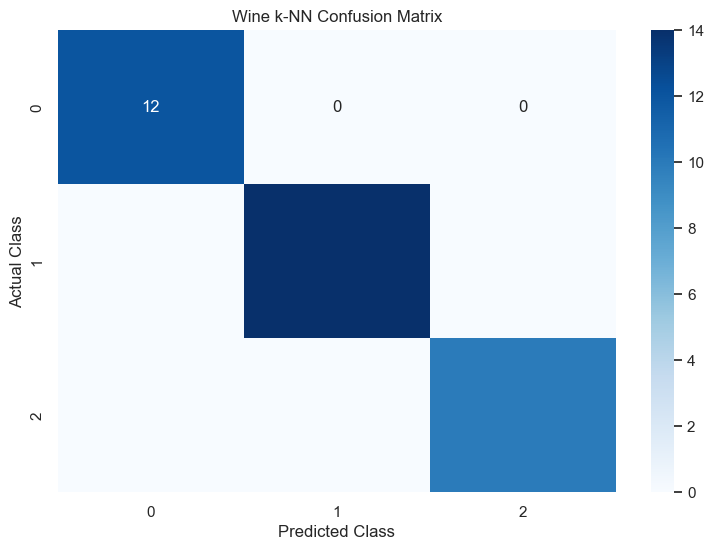

In [15]:
wine_cm = confusion_matrix(y_test_wine, y_pred_wine)

plt.figure()
sns.heatmap(
    wine_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Wine k-NN Confusion Matrix")
plt.show()


## Step 2.9 — Wine PCA Scatter Plot

The first two principal components provide a two-dimensional view of the transformed wine observations.

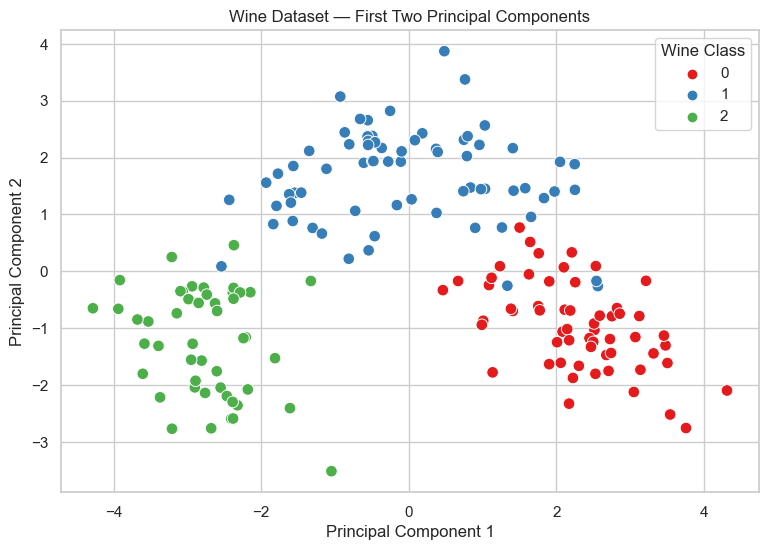

In [16]:
X_wine_pca_all = PCA(n_components=2).fit_transform(
    StandardScaler().fit_transform(X_wine)
)

plt.figure()
sns.scatterplot(
    x=X_wine_pca_all[:, 0],
    y=X_wine_pca_all[:, 1],
    hue=y_wine,
    palette="Set1",
    s=70
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Wine Dataset — First Two Principal Components")
plt.legend(title="Wine Class")
plt.show()


### Wine Classification Interpretation

The PCA step reduces the original chemical feature space while preserving at least 95% of its variance. The tuned k-NN model then classifies wines using the most informative transformed features. The test accuracy and classification report above provide the final performance assessment.

# Part 2 — Agricultural Feed Recommendation System

### Objective
Use the `chickwts` dataset as a proxy for feed-product performance.

Because the supplied dataset contains one numerical performance variable (`weight`) and a categorical feed type, we first calculate the **average weight for each feed type**. We then standardize those feed-level values, apply one-component PCA, calculate cosine similarity, and recommend the most similar feed types.

This feed-level aggregation avoids treating individual chickens as if each one were a separate feed product.

## Step 3.1 — Inspect Feed Types

In [17]:
print("Number of feed types:", chickwts["feed"].nunique())
print("\nFeed types:")
print(chickwts["feed"].unique())

print("\nNumber of observations per feed:")
display(chickwts["feed"].value_counts().sort_index())


Number of feed types: 6

Feed types:
['horsebean' 'linseed' 'soybean' 'sunflower' 'meatmeal' 'casein']

Number of observations per feed:


feed
casein       12
horsebean    10
linseed      12
meatmeal     11
soybean      13
sunflower    12
Name: count, dtype: int64

## Step 3.2 — Calculate Average Performance by Feed Type

In [19]:
feed_summary = (
    chickwts
    .groupby("feed")["weight"]
    .agg(
        mean_weight="mean",
        std_weight="std",
        count="count"
    )
    .reset_index()
)

display(feed_summary.sort_values("mean_weight", ascending=False))

,feed,mean_weight,std_weight,count
5,sunflower,328.916667,48.836384,12
0,casein,323.583333,64.433840,12
3,meatmeal,276.909091,64.900623,11
4,soybean,246.307692,56.337354,13
2,linseed,218.750000,52.235698,12
1,horsebean,160.200000,38.625841,10


## Step 3.3 — Standardize the Feed Performance Feature

In [20]:
feed_features = feed_summary[["mean_weight"]].copy()

feed_scaler = StandardScaler()
feed_scaled = feed_scaler.fit_transform(feed_features)

scaled_feed_df = pd.DataFrame(
    feed_scaled,
    columns=["standardized_mean_weight"],
    index=feed_summary["feed"]
)

display(scaled_feed_df)


,standardized_mean_weight
feed,
casein,1.091793
horsebean,-1.674993
linseed,-0.683488
meatmeal,0.301396
soybean,-0.216818
sunflower,1.182109


## Step 3.4 — Apply PCA to One Principal Component

In [21]:
feed_pca = PCA(n_components=1)

feed_pca_data = feed_pca.fit_transform(feed_scaled)

feed_pca_df = pd.DataFrame(
    feed_pca_data,
    columns=["PC1"],
    index=feed_summary["feed"]
)

print("Explained variance by PC1:",
      round(feed_pca.explained_variance_ratio_[0], 4))

display(feed_pca_df)


Explained variance by PC1: 1.0


,PC1
feed,
casein,-1.091793
horsebean,1.674993
linseed,0.683488
meatmeal,-0.301396
soybean,0.216818
sunflower,-1.182109


## Step 3.5 — Calculate Cosine Similarity

Cosine similarity measures how similarly two feed profiles point in feature space.

Because this example uses only one principal component, the similarity will mainly reflect whether two feed types have similar standardized performance levels. With a single dimension, cosine similarity can be close to `1` or `-1`, so the results should be interpreted as a simple proxy rather than a complete commercial recommendation engine.

In [22]:
similarity_matrix = cosine_similarity(feed_pca_data)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=feed_summary["feed"],
    columns=feed_summary["feed"]
)

display(similarity_df.round(3))


feed,casein,horsebean,linseed,meatmeal,soybean,sunflower
feed,,,,,,
casein,1.0,-1.0,-1.0,1.0,-1.0,1.0
horsebean,-1.0,1.0,1.0,-1.0,1.0,-1.0
linseed,-1.0,1.0,1.0,-1.0,1.0,-1.0
meatmeal,1.0,-1.0,-1.0,1.0,-1.0,1.0
soybean,-1.0,1.0,1.0,-1.0,1.0,-1.0
sunflower,1.0,-1.0,-1.0,1.0,-1.0,1.0


## Step 3.6 — Create a Recommendation Function

In [23]:
def recommend_feeds(feed_name, similarity_table, n=3):
    if feed_name not in similarity_table.index:
        raise ValueError(
            f"'{feed_name}' is not available. "
            f"Choose from: {list(similarity_table.index)}"
        )

    recommendations = (
        similarity_table[feed_name]
        .drop(feed_name)
        .sort_values(ascending=False)
        .head(n)
        .reset_index()
    )

    recommendations.columns = ["recommended_feed", "cosine_similarity"]
    return recommendations

# Example recommendation
example_feed = feed_summary.sort_values("mean_weight", ascending=False)["feed"].iloc[0]

print("Example query feed:", example_feed)
display(recommend_feeds(example_feed, similarity_df, n=3))


Example query feed: sunflower


,recommended_feed,cosine_similarity
0,casein,1.0
1,meatmeal,1.0
2,horsebean,-1.0


## Step 3.7 — Generate Recommendations for Every Feed

In [24]:
all_recommendations = []

for feed_name in similarity_df.index:
    recs = recommend_feeds(feed_name, similarity_df, n=3)
    recs.insert(0, "query_feed", feed_name)
    all_recommendations.append(recs)

all_recommendations = pd.concat(
    all_recommendations,
    ignore_index=True
)

display(all_recommendations)


,query_feed,recommended_feed,cosine_similarity
0,casein,meatmeal,1.0
1,casein,sunflower,1.0
2,casein,horsebean,-1.0
3,horsebean,linseed,1.0
4,horsebean,soybean,1.0
5,horsebean,casein,-1.0
6,linseed,horsebean,1.0
7,linseed,soybean,1.0
8,linseed,casein,-1.0
9,meatmeal,casein,1.0


## Step 3.8 — Visualize Average Feed Performance

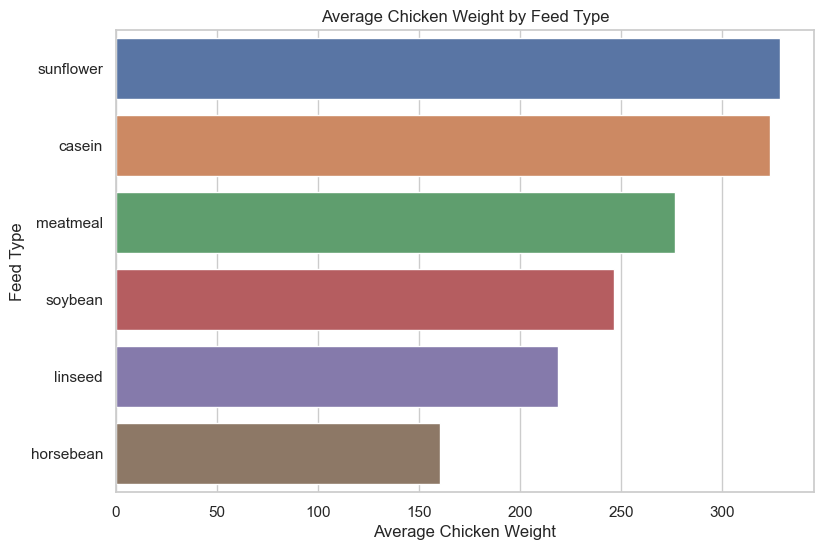

In [25]:
plt.figure()
sns.barplot(
    data=feed_summary.sort_values("mean_weight", ascending=False),
    x="mean_weight",
    y="feed"
)
plt.xlabel("Average Chicken Weight")
plt.ylabel("Feed Type")
plt.title("Average Chicken Weight by Feed Type")
plt.show()


### Feed Recommendation Interpretation

The recommendation engine ranks feed types according to cosine similarity between their PCA representations. Feeds with more similar performance profiles receive higher similarity scores.

**Important limitation:** the `chickwts` dataset contains only one performance variable. A production recommendation system would ideally include several variables such as average weight gain, feed conversion ratio, cost, protein content, and other nutritional or operational measures.

# Part 3 — Regional Crime Pattern Analysis

### Objective
Discover natural groupings among US states using crime statistics.

The workflow is:
1. Remove the state-name identifier from the numerical analysis
2. Inspect feature relationships
3. Select the three most relevant crime variables
4. Standardize the selected features
5. Apply PCA to two dimensions
6. Use the elbow method to investigate K-Means cluster counts
7. Use BIC to investigate GMM component counts
8. Fit K-Means and GMM
9. Visualize and compare their cluster assignments


## Step 4.1 — Prepare USArrests

In [26]:
# State names are identifiers rather than numerical predictors.
usarrests_clean = usarrests.set_index("rownames").copy()

print("Numerical features:")
print(usarrests_clean.columns.tolist())

display(usarrests_clean.head())


Numerical features:
['Murder', 'Assault', 'UrbanPop', 'Rape']


,Murder,Assault,UrbanPop,Rape
rownames,,,,
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6


## Step 4.2 — Explore Feature Correlations

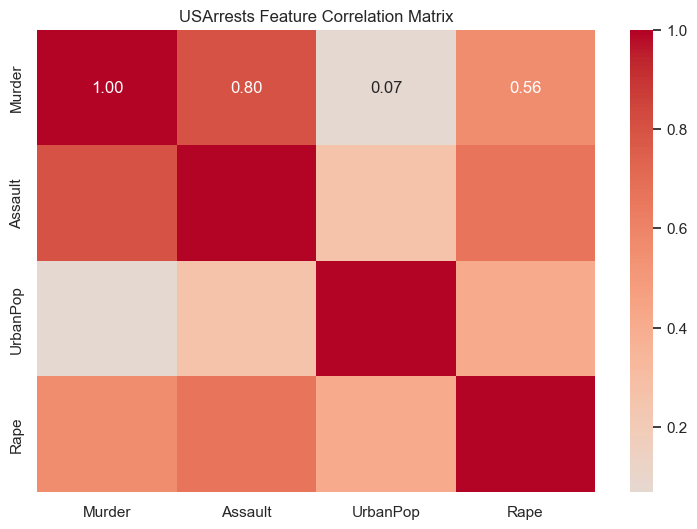

,Murder,Assault,UrbanPop,Rape
Murder,1.000000,0.801873,0.069573,0.563579
Assault,0.801873,1.000000,0.258872,0.665241
UrbanPop,0.069573,0.258872,1.000000,0.411341
Rape,0.563579,0.665241,0.411341,1.000000


In [27]:
corr = usarrests_clean.corr()

plt.figure()
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("USArrests Feature Correlation Matrix")
plt.show()

display(corr)


## Step 4.3 — Select the Top Three Relevant Features

To make the selection reproducible, we rank the four variables by their average absolute correlation with the other variables. This identifies the three variables that share the strongest overall relationships with the remaining crime measures.

In [28]:
mean_abs_corr = (
    corr.abs()
    .sum()
    .sub(1)
    .div(len(corr.columns) - 1)
    .sort_values(ascending=False)
)

print("Average absolute correlation with other variables:")
display(mean_abs_corr.to_frame("mean_absolute_correlation"))

top_3_features = mean_abs_corr.head(3).index.tolist()

print("Selected top 3 features:", top_3_features)

X_crime = usarrests_clean[top_3_features].copy()


Average absolute correlation with other variables:


,mean_absolute_correlation
Assault,0.575329
Rape,0.546720
Murder,0.478342
UrbanPop,0.246595


Selected top 3 features: ['Assault', 'Rape', 'Murder']


## Step 4.4 — Standardize the Selected Crime Features

In [29]:
crime_scaler = StandardScaler()
X_crime_scaled = crime_scaler.fit_transform(X_crime)

print("Scaled feature means:",
      np.round(X_crime_scaled.mean(axis=0), 3))
print("Scaled feature standard deviations:",
      np.round(X_crime_scaled.std(axis=0), 3))


Scaled feature means: [ 0.  0. -0.]
Scaled feature standard deviations: [1. 1. 1.]


## Step 4.5 — Apply PCA to Two Components

In [30]:
crime_pca = PCA(n_components=2)
X_crime_pca = crime_pca.fit_transform(X_crime_scaled)

print("Explained variance ratio:",
      np.round(crime_pca.explained_variance_ratio_, 4))
print("Total variance explained by two PCs:",
      round(crime_pca.explained_variance_ratio_.sum(), 4))


Explained variance ratio: [0.7862 0.1527]
Total variance explained by two PCs: 0.9389


## Step 4.6 — Visualize the Two Principal Components

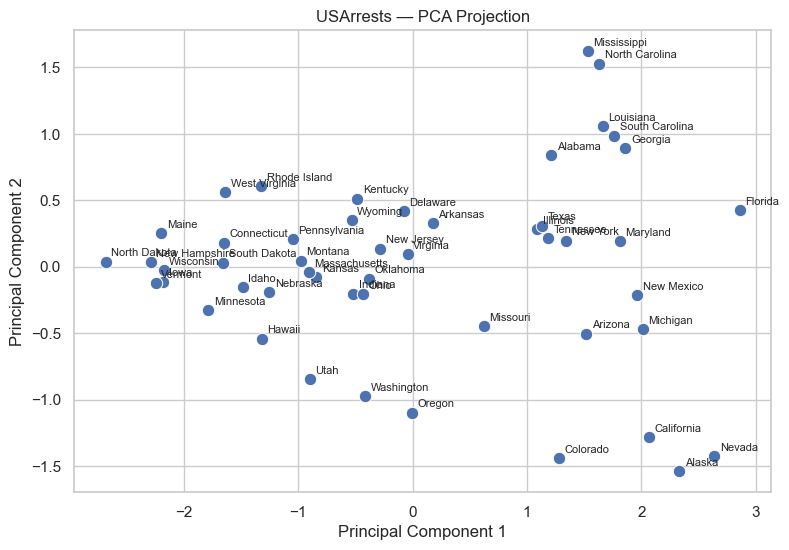

In [31]:
crime_pca_df = pd.DataFrame(
    X_crime_pca,
    columns=["PC1", "PC2"],
    index=usarrests_clean.index
)

plt.figure()
sns.scatterplot(
    data=crime_pca_df,
    x="PC1",
    y="PC2",
    s=80
)

for state, row in crime_pca_df.iterrows():
    plt.annotate(
        state,
        (row["PC1"], row["PC2"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8
    )

plt.title("USArrests — PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()


# K-Means Clustering

## Step 4.7 — Elbow Method

K-Means requires the number of clusters (`k`) to be specified. We calculate inertia for several possible values and inspect where the reduction in inertia begins to level off.

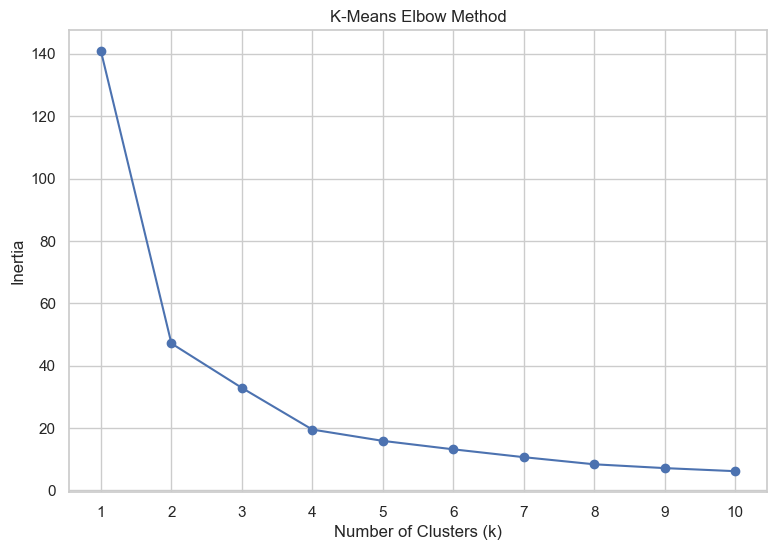

,k,inertia
0,1,140.831577
1,2,47.124496
2,3,32.872499
3,4,19.509038
4,5,15.882637
5,6,13.173982
6,7,10.656869
7,8,8.374627
8,9,7.151567
9,10,6.166756


In [32]:
k_values = range(1, 11)
inertias = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    model.fit(X_crime_pca)
    inertias.append(model.inertia_)

plt.figure()
plt.plot(k_values, inertias, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("K-Means Elbow Method")
plt.xticks(list(k_values))
plt.show()

elbow_results = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias
})

display(elbow_results)


## Step 4.8 — Choose K Using the Elbow

The elbow plot should be interpreted visually rather than treating the lowest inertia as automatically optimal, because inertia always decreases as more clusters are added.

For this dataset, we use **4 clusters**, a commonly interpretable choice for the USArrests structure, and then verify the resulting grouping with silhouette score.

In [33]:
kmeans_k = 4

kmeans = KMeans(
    n_clusters=kmeans_k,
    random_state=42,
    n_init=20
)

kmeans_labels = kmeans.fit_predict(X_crime_pca)

kmeans_silhouette = silhouette_score(
    X_crime_pca,
    kmeans_labels
)

print("Chosen K:", kmeans_k)
print("K-Means inertia:", round(kmeans.inertia_, 3))
print("K-Means silhouette score:", round(kmeans_silhouette, 4))


Chosen K: 4
K-Means inertia: 19.509
K-Means silhouette score: 0.4643


## Step 4.9 — Visualize K-Means Clusters

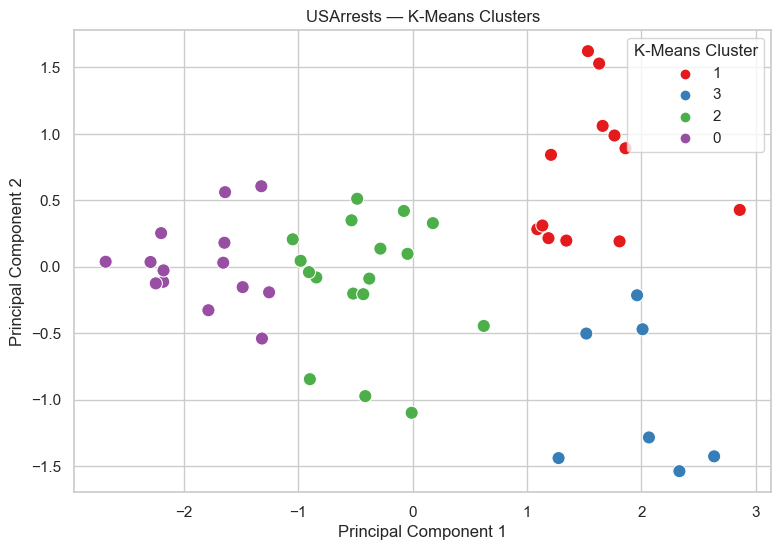

In [34]:
kmeans_plot = crime_pca_df.copy()
kmeans_plot["cluster"] = kmeans_labels.astype(str)

plt.figure()
sns.scatterplot(
    data=kmeans_plot,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="Set1",
    s=90
)

plt.title("USArrests — K-Means Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="K-Means Cluster")
plt.show()


## Step 4.10 — List States by K-Means Cluster

In [35]:
kmeans_assignments = pd.DataFrame({
    "State": usarrests_clean.index,
    "KMeans_Cluster": kmeans_labels
}).sort_values(["KMeans_Cluster", "State"])

display(kmeans_assignments)


,State,KMeans_Cluster
6,Connecticut,0
10,Hawaii,0
11,Idaho,0
14,Iowa,0
18,Maine,0
22,Minnesota,0
26,Nebraska,0
28,New Hampshire,0
33,North Dakota,0
38,Rhode Island,0


# Gaussian Mixture Model (GMM)

## Step 4.11 — Select the Number of GMM Components Using BIC

Unlike K-Means, GMM assigns probabilities to observations belonging to each component. BIC balances model fit against model complexity.

Lower BIC values indicate a better trade-off between fit and complexity.

,components,BIC,AIC
0,1,307.212112,297.651997
1,2,293.280223,272.247970
2,3,301.220189,268.715798
3,4,309.898642,265.922113
4,5,311.592281,256.143614
5,6,313.541940,246.621135
6,7,317.212584,238.819641
7,8,331.646933,241.781852
8,9,355.175578,253.838359
9,10,359.739635,246.930277


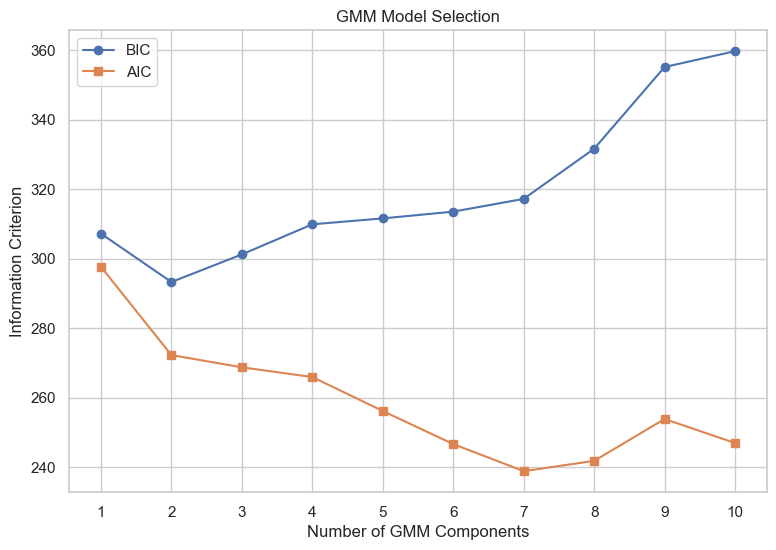

In [36]:
component_values = range(1, 11)
bic_scores = []
aic_scores = []

for n_components in component_values:
    gmm_model = GaussianMixture(
        n_components=n_components,
        covariance_type="full",
        random_state=42,
        n_init=10
    )
    gmm_model.fit(X_crime_pca)
    bic_scores.append(gmm_model.bic(X_crime_pca))
    aic_scores.append(gmm_model.aic(X_crime_pca))

gmm_results = pd.DataFrame({
    "components": list(component_values),
    "BIC": bic_scores,
    "AIC": aic_scores
})

display(gmm_results)

plt.figure()
plt.plot(component_values, bic_scores, marker="o", label="BIC")
plt.plot(component_values, aic_scores, marker="s", label="AIC")
plt.xlabel("Number of GMM Components")
plt.ylabel("Information Criterion")
plt.title("GMM Model Selection")
plt.legend()
plt.xticks(list(component_values))
plt.show()


## Step 4.12 — Fit the GMM Using the Minimum BIC

Rather than manually guessing the GMM component count, we select the number that produces the lowest BIC.

In [37]:
best_gmm_components = int(
    gmm_results.loc[gmm_results["BIC"].idxmin(), "components"]
)

gmm = GaussianMixture(
    n_components=best_gmm_components,
    covariance_type="full",
    random_state=42,
    n_init=10
)

gmm_labels = gmm.fit_predict(X_crime_pca)
gmm_probabilities = gmm.predict_proba(X_crime_pca)

print("Selected number of GMM components:", best_gmm_components)
print("Minimum BIC:",
      round(gmm_results["BIC"].min(), 3))


Selected number of GMM components: 2
Minimum BIC: 293.28


## Step 4.13 — Visualize GMM Clusters

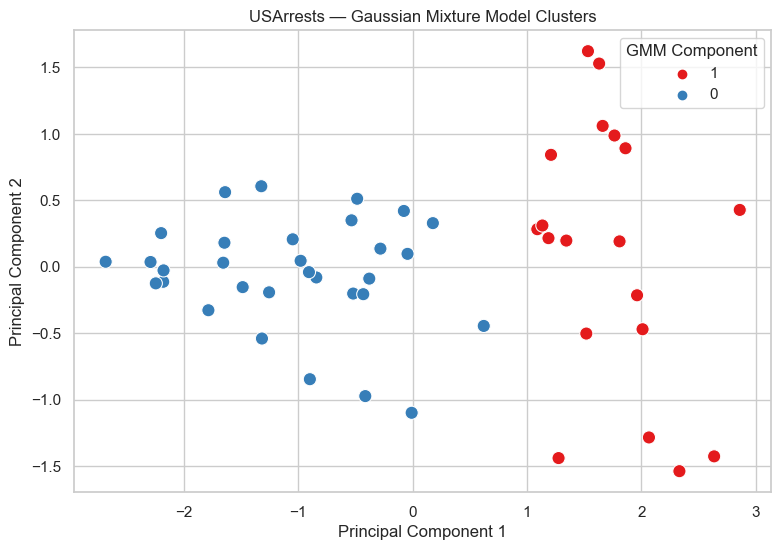

In [38]:
gmm_plot = crime_pca_df.copy()
gmm_plot["cluster"] = gmm_labels.astype(str)

plt.figure()
sns.scatterplot(
    data=gmm_plot,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="Set1",
    s=90
)

plt.title("USArrests — Gaussian Mixture Model Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="GMM Component")
plt.show()


## Step 4.14 — GMM State Assignments and Probabilities

In [39]:
gmm_assignments = pd.DataFrame({
    "State": usarrests_clean.index,
    "GMM_Component": gmm_labels
})

max_probabilities = gmm_probabilities.max(axis=1)

gmm_assignments["Max_Membership_Probability"] = max_probabilities

display(
    gmm_assignments.sort_values(
        ["GMM_Component", "State"]
    )
)


,State,GMM_Component,Max_Membership_Probability
3,Arkansas,0,0.987282
6,Connecticut,0,1.000000
7,Delaware,0,0.998154
10,Hawaii,0,1.000000
11,Idaho,0,1.000000
13,Indiana,0,0.999997
14,Iowa,0,1.000000
15,Kansas,0,1.000000
16,Kentucky,0,0.999955
18,Maine,0,1.000000


## Step 4.15 — Compare K-Means and GMM Assignments

In [40]:
comparison = pd.DataFrame({
    "State": usarrests_clean.index,
    "KMeans_Cluster": kmeans_labels,
    "GMM_Component": gmm_labels
})

display(comparison.sort_values("State"))

print("K-Means cluster sizes:")
print(pd.Series(kmeans_labels).value_counts().sort_index())

print("\nGMM component sizes:")
print(pd.Series(gmm_labels).value_counts().sort_index())


,State,KMeans_Cluster,GMM_Component
0,Alabama,1,1
1,Alaska,3,1
2,Arizona,3,1
3,Arkansas,2,0
4,California,3,1
5,Colorado,3,1
6,Connecticut,0,0
7,Delaware,2,0
8,Florida,1,1
9,Georgia,1,1


K-Means cluster sizes:
0    14
1    12
2    17
3     7
Name: count, dtype: int64

GMM component sizes:
0    31
1    19
Name: count, dtype: int64


# Step 5 — Final Results Summary

The following cell creates a compact summary of the main model results.

In [41]:
print("=" * 60)
print("FINAL MODEL SUMMARY")
print("=" * 60)

print("\n1. WINE CLASSIFICATION")
print("PCA components retained:", wine_pca.n_components_)
print("PCA variance retained:",
      round(wine_pca.explained_variance_ratio_.sum(), 4))
print("Best k-NN parameters:", knn_grid.best_params_)
print("Cross-validation accuracy:",
      round(knn_grid.best_score_, 4))
print("Test accuracy:", round(wine_accuracy, 4))

print("\n2. FEED RECOMMENDATION")
print("Number of feed types:", feed_summary.shape[0])
print("PCA components:", feed_pca.n_components_)
print("PCA variance retained:",
      round(feed_pca.explained_variance_ratio_.sum(), 4))

print("\n3. USARRESTS CLUSTERING")
print("Selected features:", top_3_features)
print("PCA variance explained:",
      round(crime_pca.explained_variance_ratio_.sum(), 4))
print("K-Means clusters:", kmeans_k)
print("K-Means silhouette score:",
      round(kmeans_silhouette, 4))
print("GMM components selected by BIC:", best_gmm_components)
print("Minimum GMM BIC:",
      round(gmm_results["BIC"].min(), 3))


FINAL MODEL SUMMARY

1. WINE CLASSIFICATION
PCA components retained: 10
PCA variance retained: 0.9624
Best k-NN parameters: {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'uniform'}
Cross-validation accuracy: 0.9722
Test accuracy: 1.0

2. FEED RECOMMENDATION
Number of feed types: 6
PCA components: 1
PCA variance retained: 1.0

3. USARRESTS CLUSTERING
Selected features: ['Assault', 'Rape', 'Murder']
PCA variance explained: 0.9389
K-Means clusters: 4
K-Means silhouette score: 0.4643
GMM components selected by BIC: 2
Minimum GMM BIC: 293.28


# Step 6 — Business Interpretation

### Wine Classification
The wine classifier demonstrates how chemical measurements can be transformed using PCA and classified with k-NN. Hyperparameter tuning identifies the combination of neighborhood size, distance metric, and weighting strategy that performs best under cross-validation.

### Feed Recommendation
The feed recommendation prototype uses historical chicken weight as a proxy for feed performance. PCA and cosine similarity provide a simple way to compare feed profiles. Because the dataset contains only one numerical performance variable, the recommendations should be treated as a demonstration rather than a production-ready agricultural recommendation engine.

### Regional Crime Analysis
The clustering analysis identifies groups of states with similar standardized crime profiles. PCA makes the multidimensional relationships easier to visualize. K-Means provides hard cluster assignments, while GMM provides probabilistic assignments and can represent clusters with different shapes.

### Overall Conclusion
The three projects demonstrate three different machine learning tasks:
- **Classification:** predict a known wine category.
- **Recommendation:** identify similar feed profiles.
- **Clustering:** discover previously unknown groups of states.

Together, they demonstrate a complete workflow from data preparation and dimensionality reduction to model optimization, evaluation, visualization, and business interpretation.
